# Technical Indicators Showcase

quaver ships a **pure-NumPy indicator library** with 20+ functions for building strategies.
All indicators:
- Operate on NumPy arrays
- Return arrays of the same length as input
- Pad leading positions with `NaN` where insufficient data exists
- Require no external dependencies beyond NumPy

This notebook visualises every indicator on synthetic OHLCV data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

# Generate synthetic OHLCV data (500 bars with trend + noise)
np.random.seed(42)
n = 500
trend = np.linspace(0, 20, n) + 10 * np.sin(np.linspace(0, 8 * np.pi, n))
noise = np.cumsum(np.random.randn(n) * 0.5)
close = 100 + trend + noise
high = close + np.abs(np.random.randn(n) * 1.5)
low = close - np.abs(np.random.randn(n) * 1.5)
open_ = close + np.random.randn(n) * 0.5
volume = np.abs(1_000_000 + np.random.randn(n) * 300_000).astype(float)

x = np.arange(n)
print(f"Generated {n} bars, close range: {close.min():.1f} - {close.max():.1f}")

Generated 500 bars, close range: 88.5 - 130.0


## Moving Averages: SMA & EMA

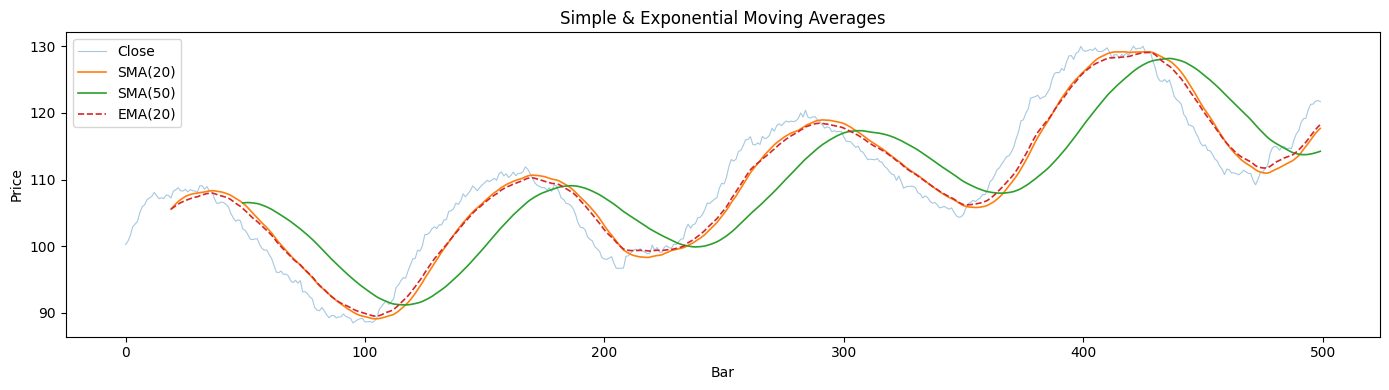

In [2]:
from quaver.strategies.indicators import sma, ema

sma_20 = sma(close, 20)
sma_50 = sma(close, 50)
ema_20 = ema(close, 20)

fig, ax = plt.subplots()
ax.plot(x, close, alpha=0.4, label="Close", linewidth=0.8)
ax.plot(x, sma_20, label="SMA(20)", linewidth=1.2)
ax.plot(x, sma_50, label="SMA(50)", linewidth=1.2)
ax.plot(x, ema_20, label="EMA(20)", linewidth=1.2, linestyle="--")
ax.set_title("Simple & Exponential Moving Averages")
ax.legend()
ax.set_xlabel("Bar")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

## Bollinger Bands

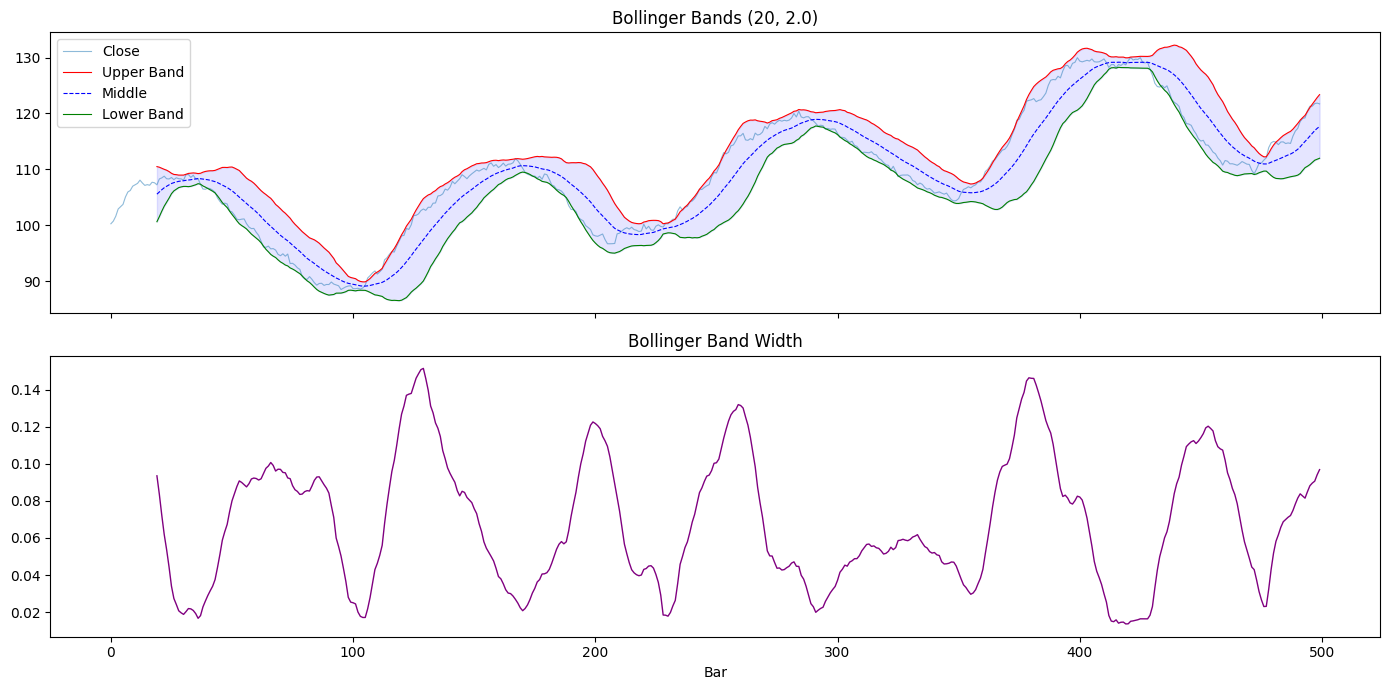

In [3]:
from quaver.strategies.indicators import bollinger_bands, bollinger_band_width

bb_upper, bb_middle, bb_lower = bollinger_bands(close, period=20, num_std=2.0)
bbw = bollinger_band_width(bb_upper, bb_middle, bb_lower)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(x, close, alpha=0.5, label="Close", linewidth=0.8)
axes[0].plot(x, bb_upper, color="red", linewidth=0.8, label="Upper Band")
axes[0].plot(x, bb_middle, color="blue", linewidth=0.8, linestyle="--", label="Middle")
axes[0].plot(x, bb_lower, color="green", linewidth=0.8, label="Lower Band")
axes[0].fill_between(x, bb_lower, bb_upper, alpha=0.1, color="blue")
axes[0].set_title("Bollinger Bands (20, 2.0)")
axes[0].legend()

axes[1].plot(x, bbw, color="purple", linewidth=1)
axes[1].set_title("Bollinger Band Width")
axes[1].set_xlabel("Bar")
plt.tight_layout()
plt.show()

## RSI (Relative Strength Index)

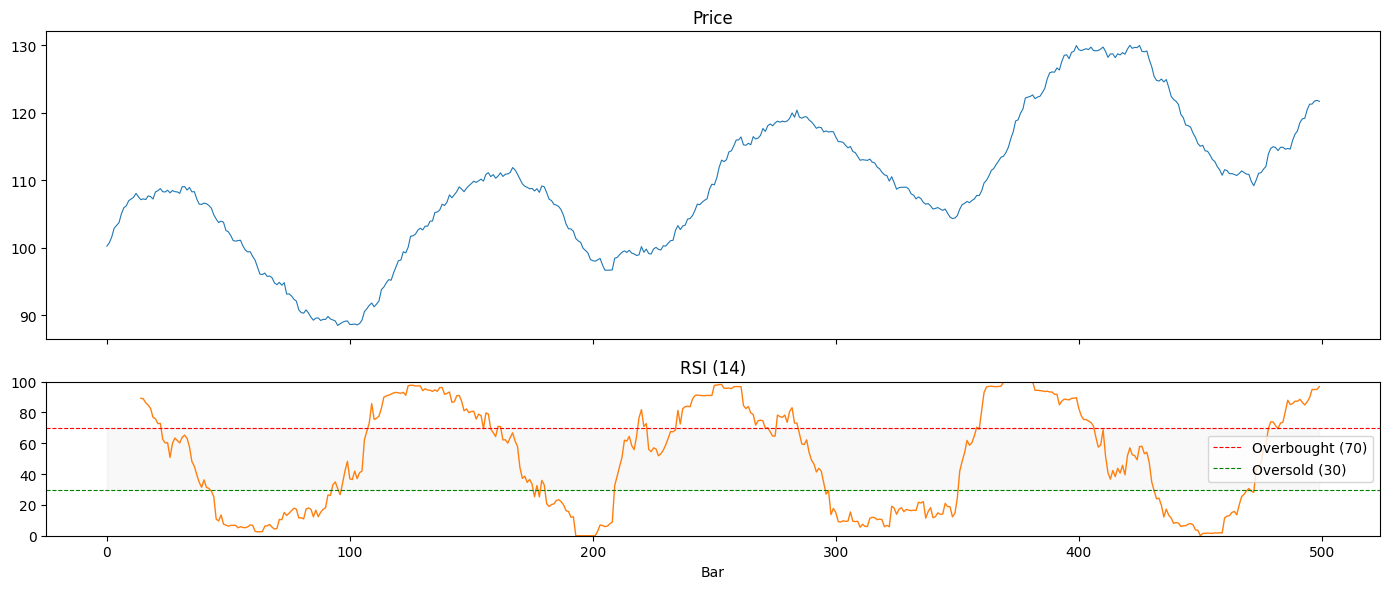

In [4]:
from quaver.strategies.indicators import rsi

rsi_14 = rsi(close, 14)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(x, close, linewidth=0.8)
axes[0].set_title("Price")

axes[1].plot(x, rsi_14, color="tab:orange", linewidth=1)
axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
axes[1].fill_between(x, 30, 70, alpha=0.05, color="grey")
axes[1].set_ylim(0, 100)
axes[1].set_title("RSI (14)")
axes[1].legend()
axes[1].set_xlabel("Bar")
plt.tight_layout()
plt.show()

## MACD (Moving Average Convergence Divergence)

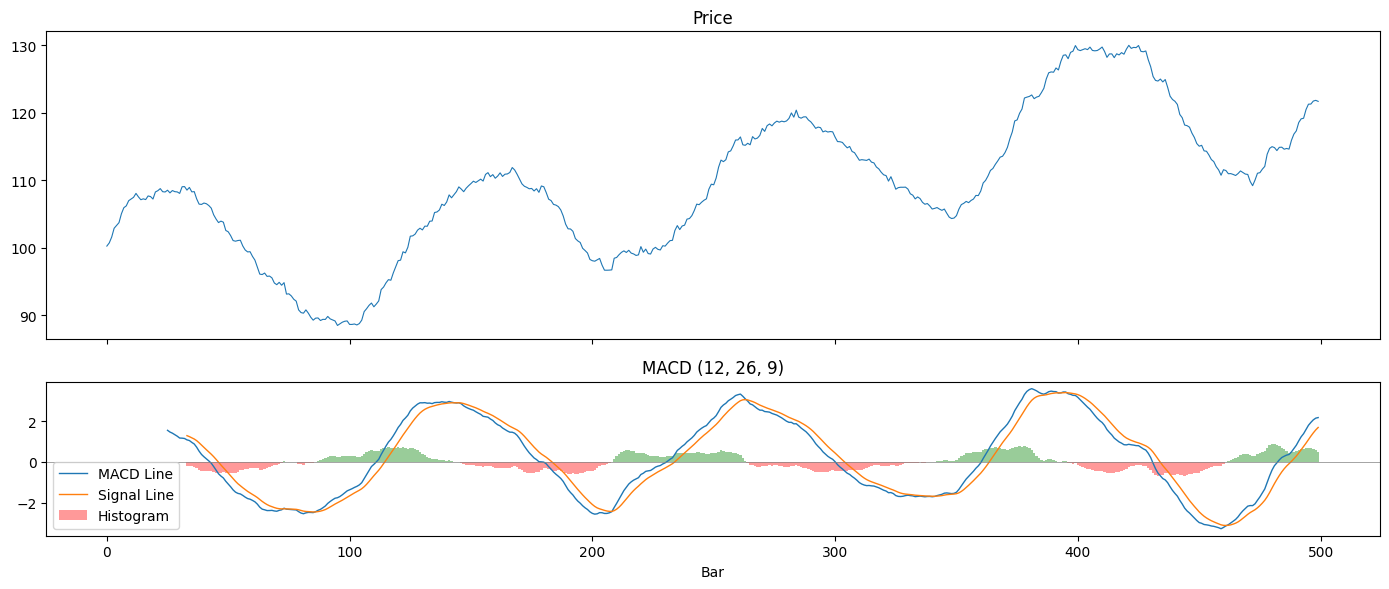

In [5]:
from quaver.strategies.indicators import macd

macd_line, signal_line, histogram = macd(close, fast=12, slow=26, signal=9)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(x, close, linewidth=0.8)
axes[0].set_title("Price")

axes[1].plot(x, macd_line, label="MACD Line", linewidth=1)
axes[1].plot(x, signal_line, label="Signal Line", linewidth=1)
colors = ["green" if v >= 0 else "red" for v in histogram]
axes[1].bar(x, histogram, color=colors, alpha=0.4, width=1.0, label="Histogram")
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_title("MACD (12, 26, 9)")
axes[1].legend()
axes[1].set_xlabel("Bar")
plt.tight_layout()
plt.show()

## Stochastic Oscillator

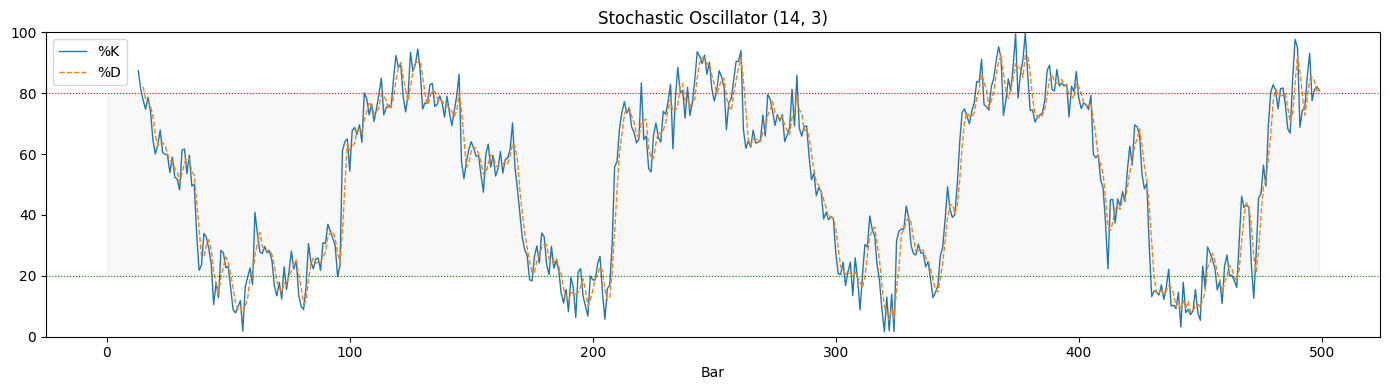

In [6]:
from quaver.strategies.indicators import stochastic

pct_k, pct_d = stochastic(high, low, close, period_k=14, period_d=3)

fig, ax = plt.subplots()
ax.plot(x, pct_k, label="%K", linewidth=1)
ax.plot(x, pct_d, label="%D", linewidth=1, linestyle="--")
ax.axhline(80, color="red", linestyle=":", linewidth=0.8)
ax.axhline(20, color="green", linestyle=":", linewidth=0.8)
ax.fill_between(x, 20, 80, alpha=0.05, color="grey")
ax.set_ylim(0, 100)
ax.set_title("Stochastic Oscillator (14, 3)")
ax.legend()
ax.set_xlabel("Bar")
plt.tight_layout()
plt.show()

## ATR (Average True Range) & ADX (Average Directional Index)

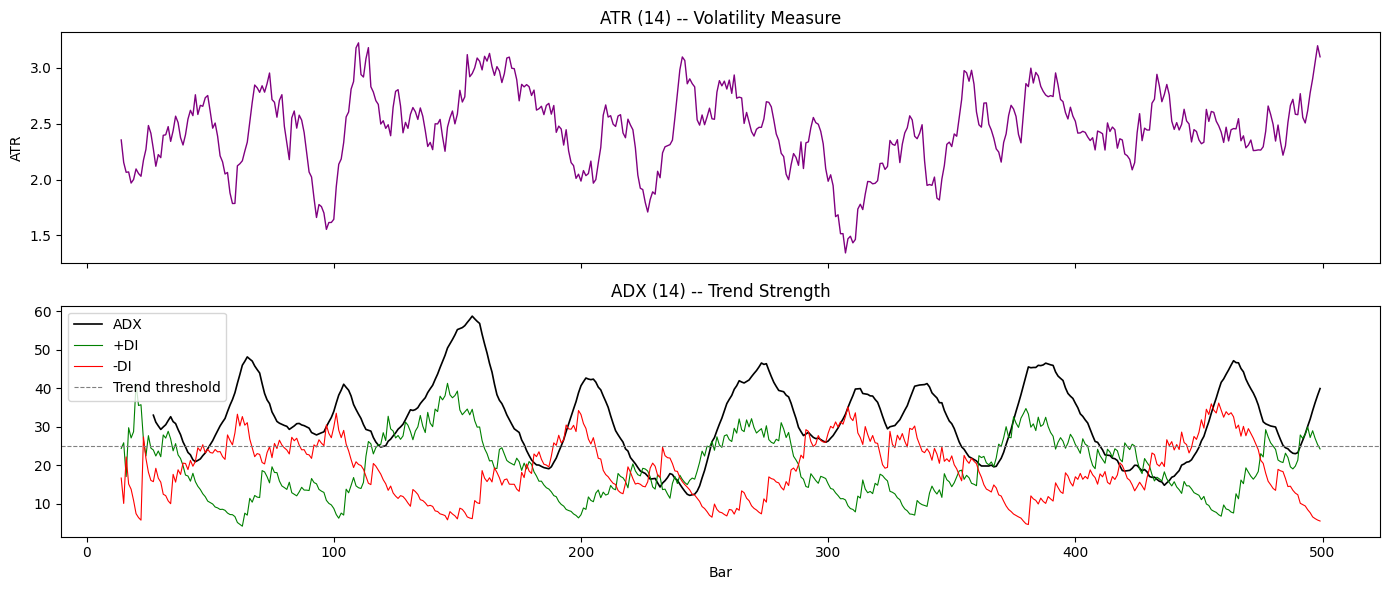

In [7]:
from quaver.strategies.indicators import atr, adx

atr_14 = atr(high, low, close, period=14)
adx_14, plus_di, minus_di = adx(high, low, close, period=14)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(x, atr_14, color="purple", linewidth=1)
axes[0].set_title("ATR (14) -- Volatility Measure")
axes[0].set_ylabel("ATR")

axes[1].plot(x, adx_14, label="ADX", linewidth=1.2, color="black")
axes[1].plot(x, plus_di, label="+DI", linewidth=0.8, color="green")
axes[1].plot(x, minus_di, label="-DI", linewidth=0.8, color="red")
axes[1].axhline(25, color="grey", linestyle="--", linewidth=0.8, label="Trend threshold")
axes[1].set_title("ADX (14) -- Trend Strength")
axes[1].legend()
axes[1].set_xlabel("Bar")
plt.tight_layout()
plt.show()

## Donchian Channels & Keltner Channels

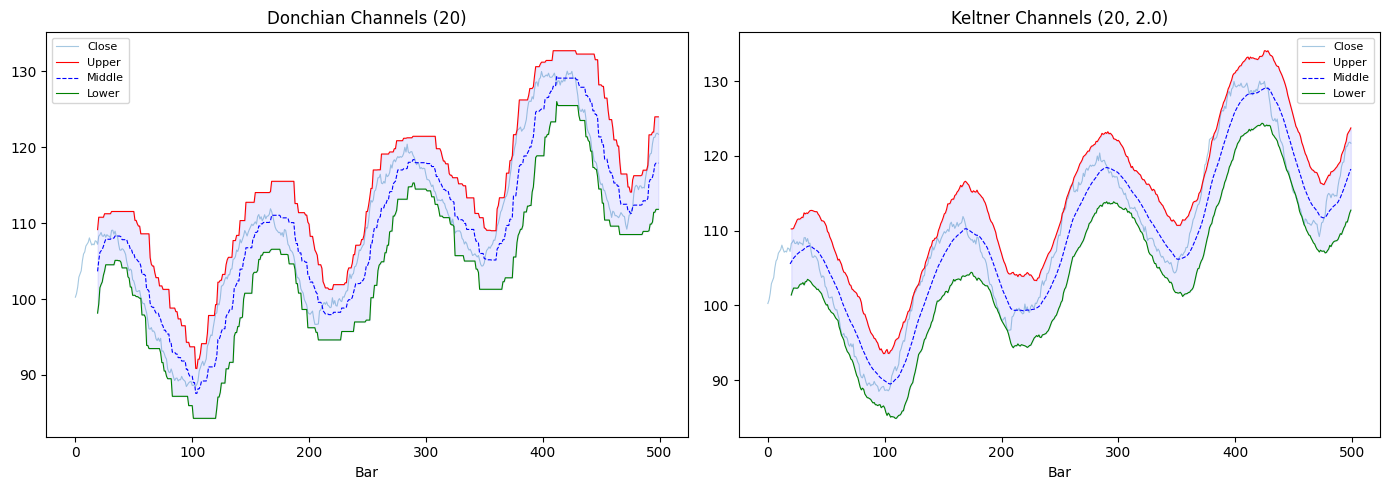

In [8]:
from quaver.strategies.indicators import donchian, keltner

don_upper, don_mid, don_lower = donchian(high, low, period=20)
kel_upper, kel_mid, kel_lower = keltner(high, low, close, period=20, multiplier=2.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (u, m, l, title) in zip(
    axes,
    [
        (don_upper, don_mid, don_lower, "Donchian Channels (20)"),
        (kel_upper, kel_mid, kel_lower, "Keltner Channels (20, 2.0)"),
    ],
):
    ax.plot(x, close, alpha=0.4, label="Close", linewidth=0.8)
    ax.plot(x, u, color="red", linewidth=0.8, label="Upper")
    ax.plot(x, m, color="blue", linewidth=0.8, linestyle="--", label="Middle")
    ax.plot(x, l, color="green", linewidth=0.8, label="Lower")
    ax.fill_between(x, l, u, alpha=0.08, color="blue")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlabel("Bar")

plt.tight_layout()
plt.show()

## Volume Indicators: OBV, VWAP, Relative Volume

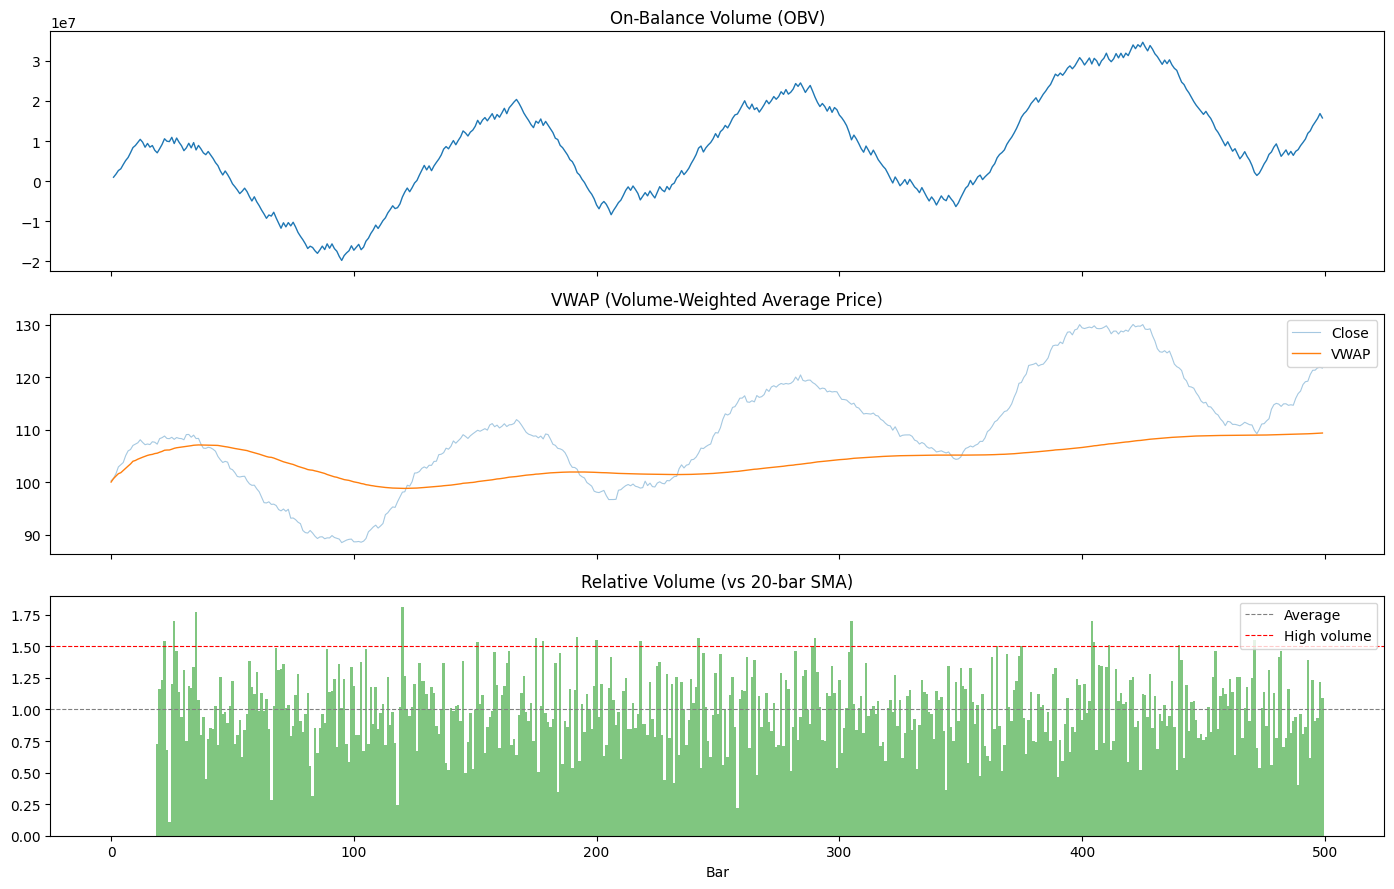

In [9]:
from quaver.strategies.indicators import obv, vwap, volume_relative

obv_val = obv(close, volume)
vwap_val = vwap(high, low, close, volume)
vol_rel = volume_relative(volume, period=20)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(x, obv_val, color="tab:blue", linewidth=1)
axes[0].set_title("On-Balance Volume (OBV)")

axes[1].plot(x, close, alpha=0.4, label="Close", linewidth=0.8)
axes[1].plot(x, vwap_val, color="tab:orange", label="VWAP", linewidth=1)
axes[1].set_title("VWAP (Volume-Weighted Average Price)")
axes[1].legend()

axes[2].bar(x, vol_rel, color="tab:green", alpha=0.6, width=1.0)
axes[2].axhline(1.0, color="grey", linestyle="--", linewidth=0.8, label="Average")
axes[2].axhline(1.5, color="red", linestyle="--", linewidth=0.8, label="High volume")
axes[2].set_title("Relative Volume (vs 20-bar SMA)")
axes[2].legend()
axes[2].set_xlabel("Bar")

plt.tight_layout()
plt.show()

## CCI (Commodity Channel Index)

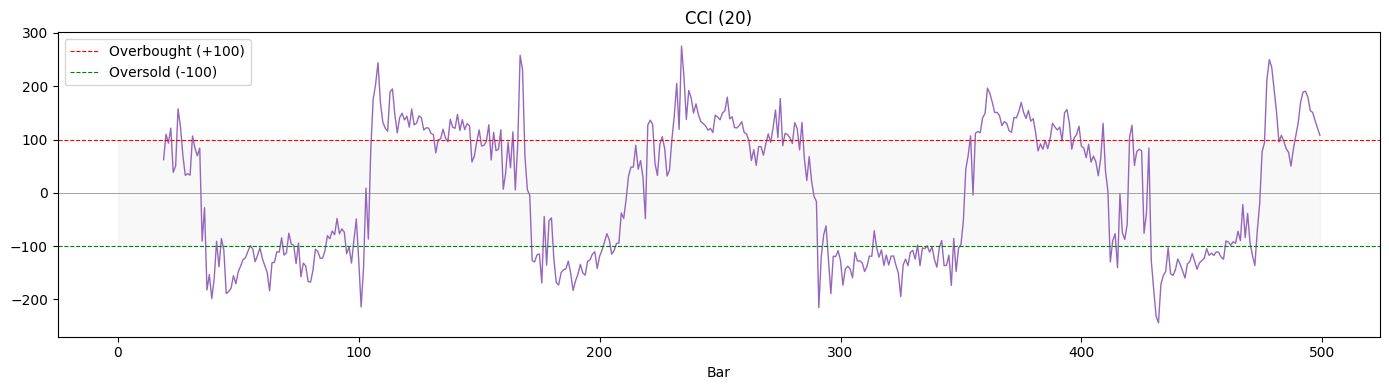

In [10]:
from quaver.strategies.indicators import cci

cci_20 = cci(high, low, close, period=20)

fig, ax = plt.subplots()
ax.plot(x, cci_20, linewidth=1, color="tab:purple")
ax.axhline(100, color="red", linestyle="--", linewidth=0.8, label="Overbought (+100)")
ax.axhline(-100, color="green", linestyle="--", linewidth=0.8, label="Oversold (-100)")
ax.axhline(0, color="grey", linewidth=0.5)
ax.fill_between(x, -100, 100, alpha=0.05, color="grey")
ax.set_title("CCI (20)")
ax.legend()
ax.set_xlabel("Bar")
plt.tight_layout()
plt.show()

## Rolling Max, Rolling Min & Rolling Percentile

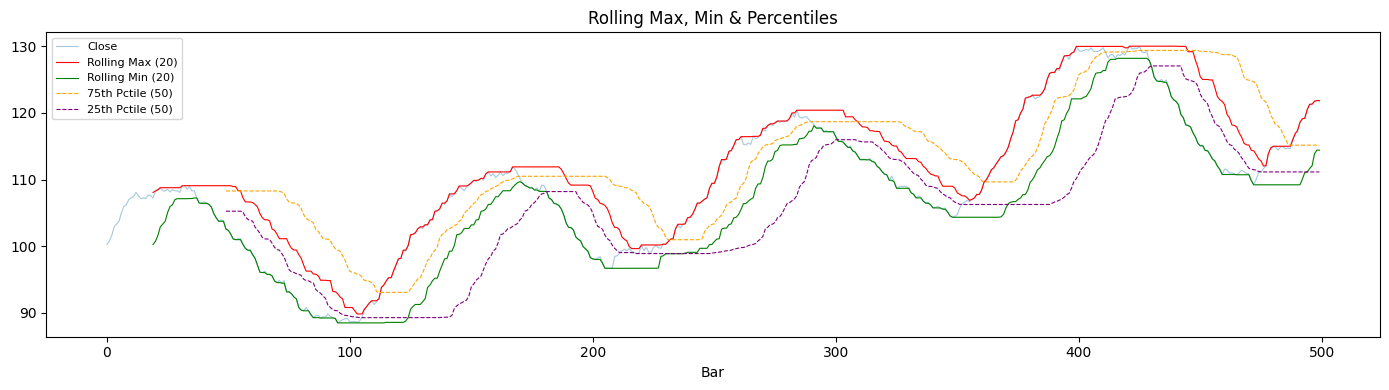

In [11]:
from quaver.strategies.indicators import rolling_max, rolling_min, rolling_percentile

rmax = rolling_max(close, 20)
rmin = rolling_min(close, 20)
rpct_75 = rolling_percentile(close, window=50, percentile=75)
rpct_25 = rolling_percentile(close, window=50, percentile=25)

fig, ax = plt.subplots()
ax.plot(x, close, alpha=0.4, label="Close", linewidth=0.8)
ax.plot(x, rmax, color="red", linewidth=0.8, label="Rolling Max (20)")
ax.plot(x, rmin, color="green", linewidth=0.8, label="Rolling Min (20)")
ax.plot(x, rpct_75, color="orange", linewidth=0.8, linestyle="--", label="75th Pctile (50)")
ax.plot(x, rpct_25, color="purple", linewidth=0.8, linestyle="--", label="25th Pctile (50)")
ax.set_title("Rolling Max, Min & Percentiles")
ax.legend(fontsize=8)
ax.set_xlabel("Bar")
plt.tight_layout()
plt.show()

## Daily Returns

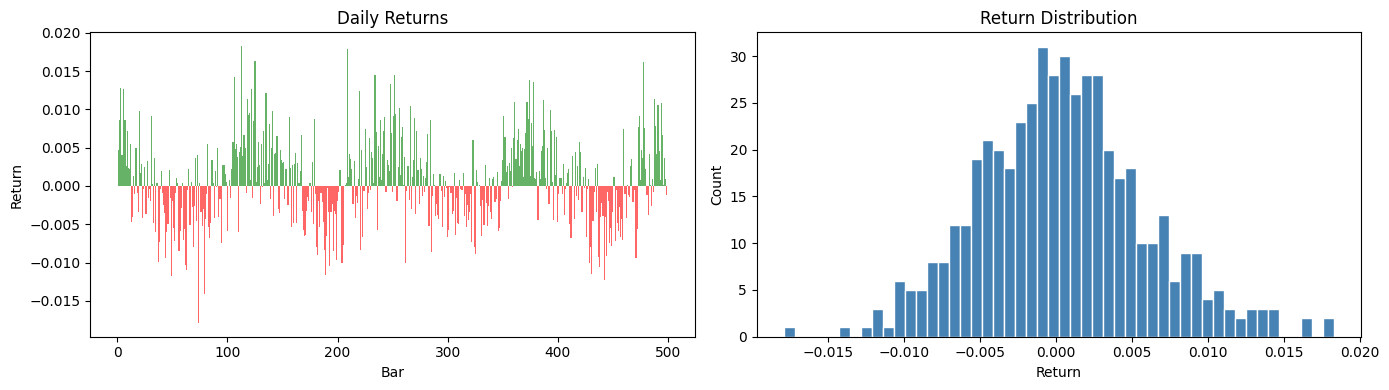

In [12]:
from quaver.strategies.indicators import daily_returns

rets = daily_returns(close)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["green" if r >= 0 else "red" for r in rets]
axes[0].bar(x, rets, color=colors, alpha=0.6, width=1.0)
axes[0].set_title("Daily Returns")
axes[0].set_xlabel("Bar")
axes[0].set_ylabel("Return")

axes[1].hist(rets[~np.isnan(rets)], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Return Distribution")
axes[1].set_xlabel("Return")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Indicator Summary

| Category | Functions |
|----------|----------|
| **Trend** | `sma`, `ema`, `macd`, `adx` |
| **Momentum** | `rsi`, `stochastic`, `cci` |
| **Volatility** | `atr`, `true_range`, `bollinger_bands`, `bollinger_band_width`, `keltner`, `donchian` |
| **Volume** | `obv`, `vwap`, `volume_relative` |
| **Statistical** | `rolling_max`, `rolling_min`, `rolling_percentile`, `daily_returns` |
| **Smoothing** | `wilder_smooth` (used internally by ATR/ADX/RSI) |

All functions live in `quaver.strategies.indicators` and accept/return NumPy arrays.